<a href="https://colab.research.google.com/github/badaraaliouguindo/heart-disease-predictor/blob/main/notebooks/01_EDA_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df = pd.read_csv(url)

print("Shape du dataset :", df.shape)
print("\nAperçu des données :")
df.head()

Shape du dataset : (303, 14)

Aperçu des données :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#  Infos générales

In [2]:
print("Types et valeurs manquantes :")
df.info()

print("\nStatistiques descriptives :")
df.describe()

Types et valeurs manquantes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Statistiques descriptives :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Distribution de la cible

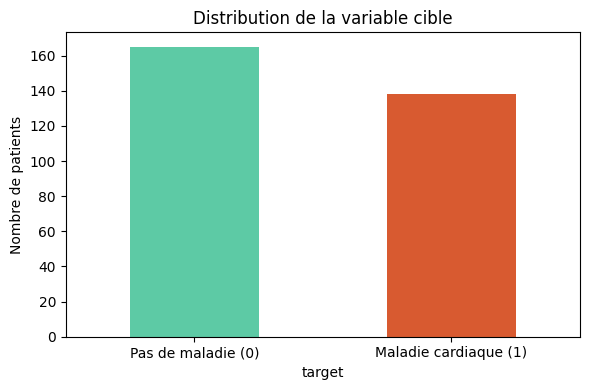

Répartition (%) :
target
1    54.5
0    45.5
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['#5DCAA5', '#D85A30'])
ax.set_title("Distribution de la variable cible")
ax.set_xticklabels(['Pas de maladie (0)', 'Maladie cardiaque (1)'], rotation=0)
ax.set_ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

print("Répartition (%) :")
print(df['target'].value_counts(normalize=True).round(3) * 100)

# Corrélations avec la cible

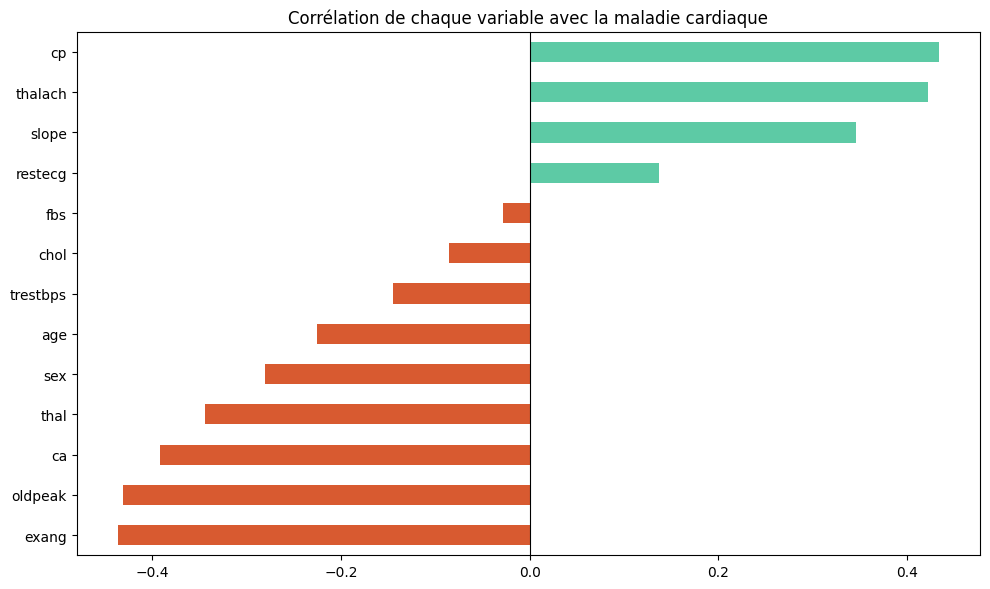

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
correlations = df.corr()['target'].drop('target').sort_values()
correlations.plot(kind='barh', ax=ax,
                  color=['#D85A30' if x < 0 else '#5DCAA5' for x in correlations])
ax.set_title("Corrélation de chaque variable avec la maladie cardiaque")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Heatmap des corrélations

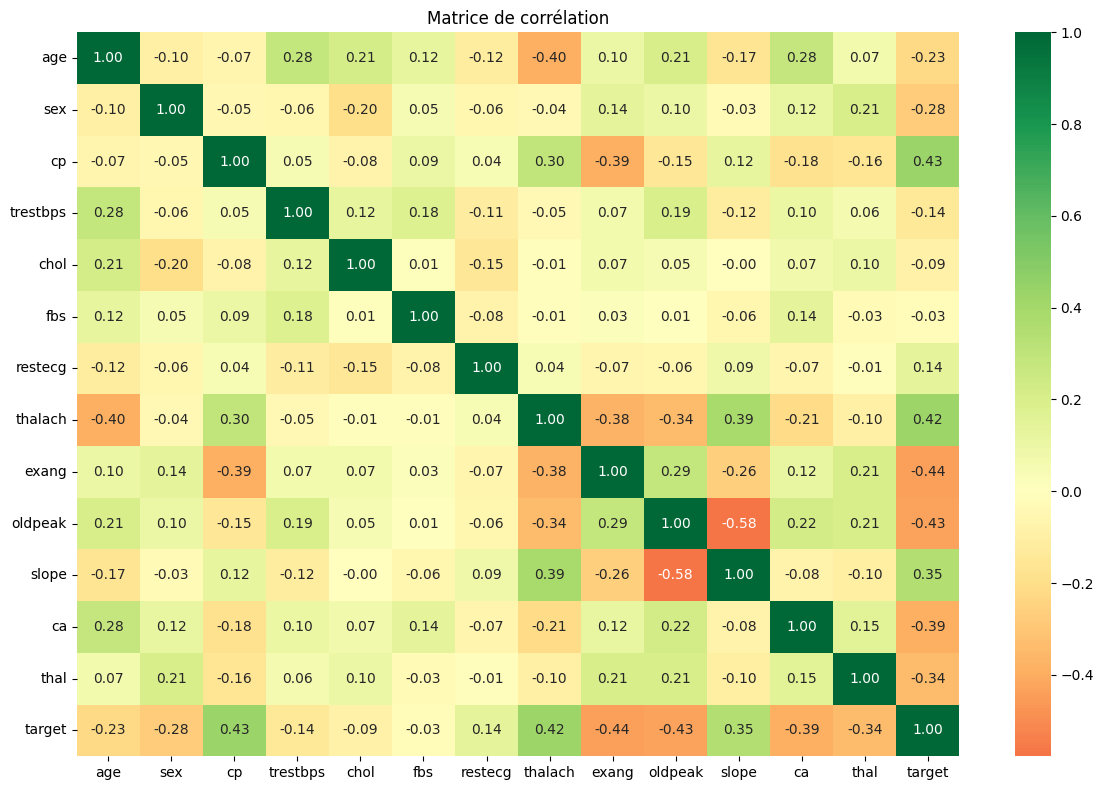

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title("Matrice de corrélation")
plt.tight_layout()
plt.show()